# Studies about gravitational waves, glitches on O3 run data - We need be able to obtain data from LIGO, HANFORD and VIRGO interferometers, manipulate this data and plot the results from O3 run.

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from gwosc.datasets import event_gps
from gwpy.timeseries import TimeSeries

## We can search for data in three ways: i) ifo: **{H1, L1, V1} from LigoDV** website or ii) ifo: **{H1, L1} from Zenodo** website and iii) directly using libraries and functions in python.

## The first and second one as follow

First we'll import the dataFrames from LIGO website (https://ldvw.ligo.caltech.edu/ldvw/gspySearch) and filter some duplicate data from them. Let's leave Hanford aside for now

In [109]:
dfligo_L1_O3a = pd.read_csv("L1_O3a_gspyLIGO.csv").drop_duplicates()
dfligo_V1_O3a = pd.read_csv("V1_O3a_gspyLIGO.csv").drop_duplicates()
# dfligo_H1_O3a = pd.read_csv("H1_O3a_gspyLIGO.csv").drop_duplicates()

dfligo_L1_O3b = pd.read_csv("L1_O3b_gspyLIGO.csv").drop_duplicates()
dfligo_V1_O3b = pd.read_csv("V1_O3b_gspyLIGO.csv").drop_duplicates()
# dfligo_H1_O3b = pd.read_csv("H1_O3b_gspyLIGO.csv").drop_duplicates()

Now for the ZENODO website (https://zenodo.org/records/5649212) data

In [110]:
dfzenodo_L1_O3a = pd.read_csv("L1_O3a_Zenodo.csv").drop_duplicates()
# dfzenodo_H1_O3a = pd.read_csv("H1_O3a_Zenodo.csv.csv").drop_duplicates()

dfzenodo_L1_O3b = pd.read_csv("L1_O3b_Zenodo.csv").drop_duplicates()
# dfzenodo_H1_O3b = pd.read_csv("H1_O3b_Zenodo.csv.csv").drop_duplicates()

We need modify the column from **"ml_label"** to **"label"** for zenodo dataFrame, because ligo dataFrame use **"label"**

In [83]:
dfzenodo_L1_O3a.rename(columns={'ml_label': 'label'}, inplace=True)
dfzenodo_L1_O3b.rename(columns={'ml_label': 'label'}, inplace=True)

In [96]:
print(dfligo_L1_O3a.columns)

Index(['GPStime', 'peakFreq', 'snr', 'amplitude', 'centralFreq', 'duration',
       'bandwidth', 'chisq', 'chisqDof', 'confidence', 'id', 'ifo', 'label',
       'imgUrl', 'Q-value', 'Fonte'],
      dtype='object')


This data has a lot of intersting columns that we can use, like **"GPStime"**, **"duration"**, **"confidence"** or **"snr"**.

We can see the O3a run in dataFrame, for exemple

In [98]:
dfligo_L1_O3a.head()

,GPStime,peakFreq,snr,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,id,ifo,label,imgUrl,Q-value,Fonte
0,1.252630e+09,30.734,14050.200,1.730000e-19,3980.241,8.250,7940.48291,0.0,0.0,1.0,xg6I5indL7,L1,Extremely_Loud,https://ldas-jobs.ligo-la.caltech.edu/~gravity...,11.314,ligo ifo L1
1,1.242889e+09,39.789,12802.310,1.020000e-19,3980.241,10.669,7940.48291,0.0,0.0,1.0,puprGzhePt,L1,Extremely_Loud,https://ldas-jobs.ligo-la.caltech.edu/~gravity...,11.314,ligo ifo L1
2,1.243172e+09,39.789,12470.565,1.030000e-19,3980.241,7.875,7940.48291,0.0,0.0,1.0,wVuUvshkGV,L1,Extremely_Loud,https://ldas-jobs.ligo-la.caltech.edu/~gravity...,11.314,ligo ifo L1
3,1.241942e+09,39.789,10580.012,8.610000e-20,3980.241,9.073,7940.48291,0.0,0.0,1.0,UR5QrA8PQs,L1,Extremely_Loud,https://ldas-jobs.ligo-la.caltech.edu/~gravity...,11.314,ligo ifo L1
4,1.240748e+09,39.789,10457.896,1.030000e-19,3980.241,8.500,7940.48291,0.0,0.0,1.0,nKTwtpEv3b,L1,Extremely_Loud,https://ldas-jobs.ligo-la.caltech.edu/~gravity...,11.314,ligo ifo L1


Each line is a single **Glitch**, and the columns represent its **parameters**

## Analyze the frequency of each categorized glitch of O3 in general, but also splitting the analysis for O3a (April 1st 2019 - October 1st 2019) and O3b (November 1st 2019 - March 27th 2020) runs;

Now we'll see the frequence of each glitch for O3a run, from both LIGO and ZENODO websites

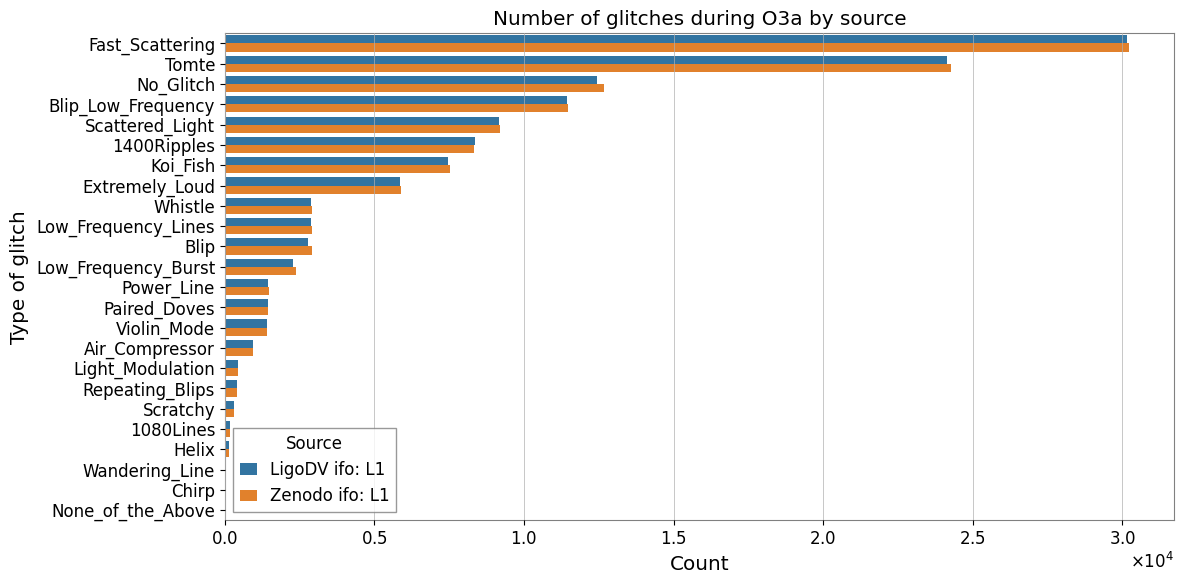

In [104]:
# Adiciona a origem
dfligo_L1_O3a['Fonte'] = 'LigoDV ifo: L1'
dfzenodo_L1_O3a['Fonte'] = 'Zenodo ifo: L1'

# Junta os dois DataFrames
df_combined = pd.concat([dfligo_L1_O3a, dfzenodo_L1_O3a])

# Garante que a ordem seja pela soma total de ocorrências
ordered_labels = (
    df_combined['label']
    .value_counts()
    .loc[lambda x: x.index.isin(df_combined['label'].unique())]
    .index
)

# Gráfico
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_combined,
    y='label',
    hue='Fonte',
    order=ordered_labels,
    dodge=True  # reforça o uso de barras lado a lado
)

plt.title("Number of glitches during O3a by source")
plt.xlabel("Count")
plt.ylabel("Type of glitch")
plt.legend(title='Source')
plt.tight_layout()
plt.show()

And for O3b run too

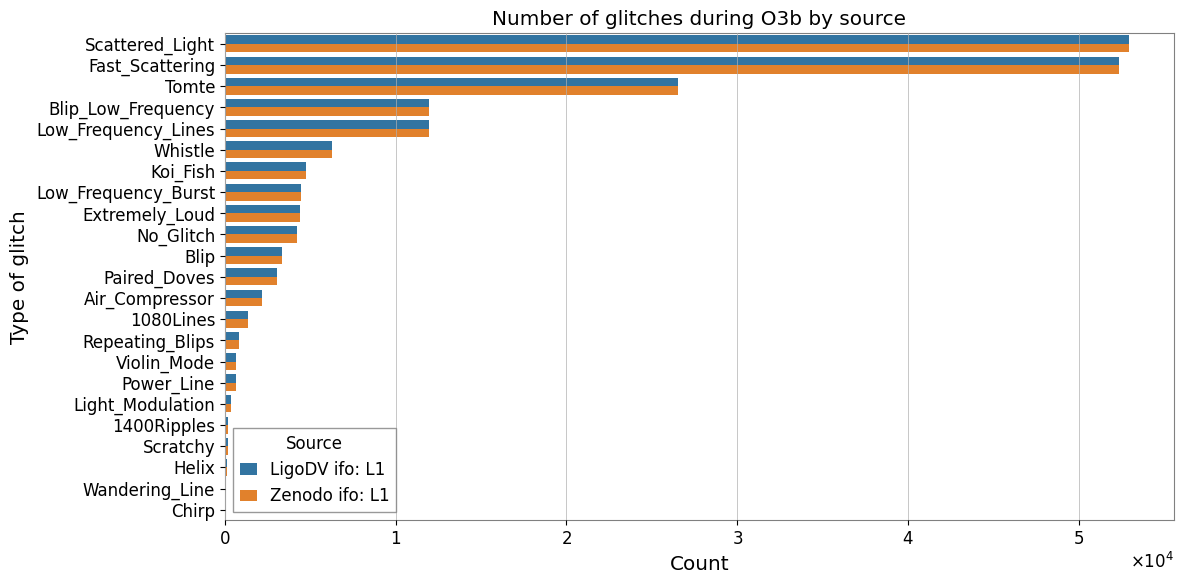

In [105]:
# Adiciona a origem
dfligo_L1_O3b['Fonte'] = 'LigoDV ifo: L1'
dfzenodo_L1_O3b['Fonte'] = 'Zenodo ifo: L1'

# Junta os dois DataFrames
df_combined = pd.concat([dfligo_L1_O3b, dfzenodo_L1_O3b])

# Garante que a ordem seja pela soma total de ocorrências
ordered_labels = (
    df_combined['label']
    .value_counts()
    .loc[lambda x: x.index.isin(df_combined['label'].unique())]
    .index
)

# Gráfico
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_combined,
    y='label',
    hue='Fonte',
    order=ordered_labels,
    dodge=True  # reforça o uso de barras lado a lado
)

plt.title("Number of glitches during O3b by source")
plt.xlabel("Count")
plt.ylabel("Type of glitch")
plt.legend(title='Source')
plt.tight_layout()
plt.show()


We can see that fast-scattering and scattering-light are the glitches that occurred the most during the O3b run - around November 1st 2019 - March 27th 2020. This agreed with Tabata teses (https://www.gov.br/inpe/pt-br/area-conhecimento/posgraduacao/ast/repositorio-de-arquivos/teses/tese_tabata_aira_ferreira.pdf).

The LIGO website has data from V1 interferometer, let we see

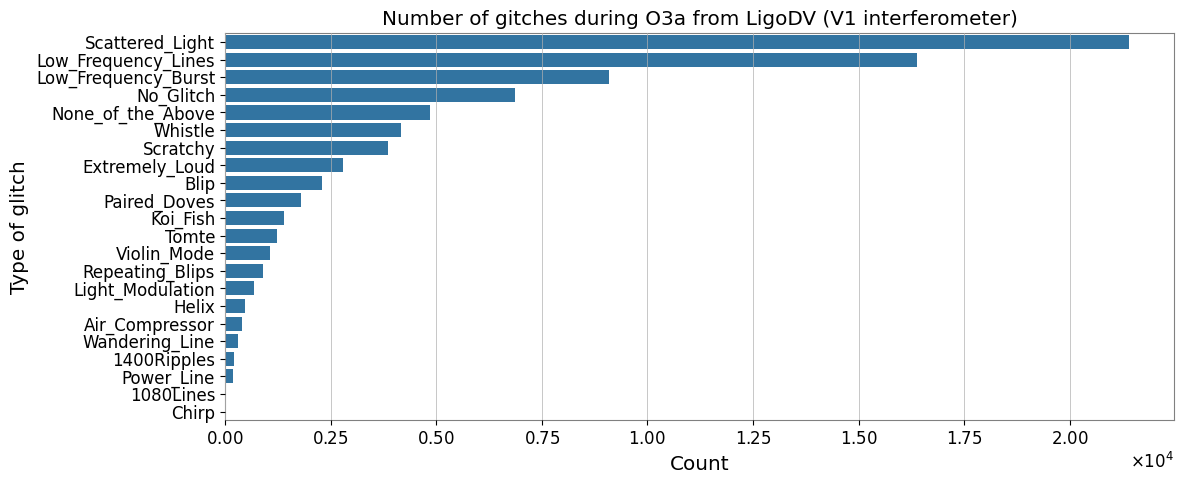

In [106]:
plt.figure(figsize=(12, 5))

sns.countplot(data=dfligo_V1_O3a, y='label', order=dfligo_V1_O3a['label'].value_counts().index)
plt.title("Number of gitches during O3a from LigoDV (V1 interferometer)")
plt.xlabel("Count")
plt.ylabel("Type of glitch")

plt.tight_layout()
plt.show()

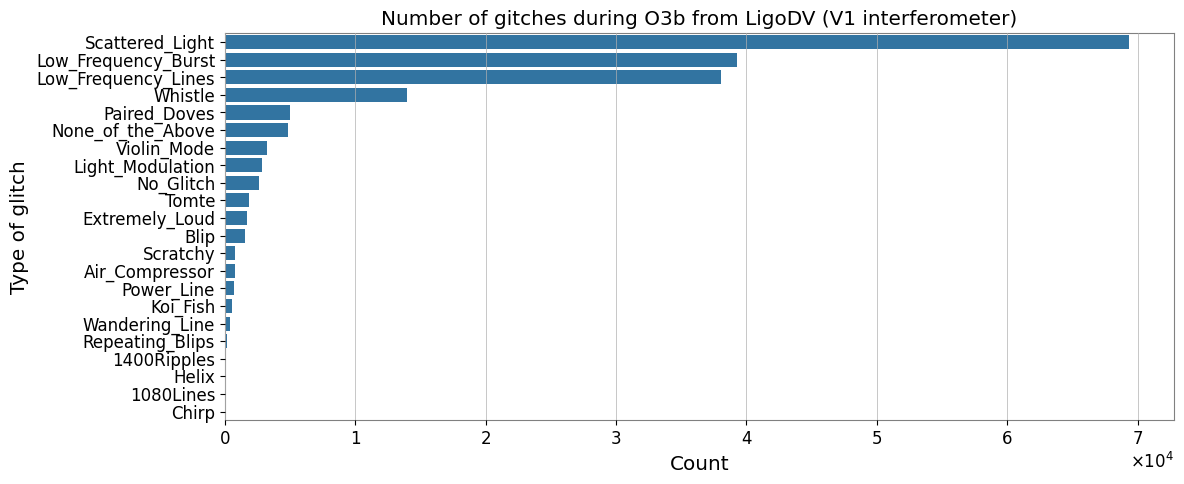

In [107]:
plt.figure(figsize=(12, 5))

sns.countplot(data=dfligo_V1_O3b, y='label', order=dfligo_V1_O3b['label'].value_counts().index)
plt.title("Number of gitches during O3b from LigoDV (V1 interferometer)")
plt.xlabel("Count")
plt.ylabel("Type of glitch")

plt.tight_layout()
plt.show()

## The third one as follow

In [53]:
pip install gwpy gwosc pandas matplotlib seaborn

# Time-tracking of the incidence of each glitch category throughout O3 (monthly, by season, …);